# EDA 001.01 — Handling Missing Values

**Kaggle Data Cleaning Course — Lesson 1**

Missing data is one of the most common problems in real-world datasets. In this notebook we learn:

1. **Why** data goes missing (MCAR, MAR, MNAR)
2. How to **detect** missing values
3. How to **visualize** missingness patterns
4. Strategies to **handle** missing values — dropping vs. imputation
5. Comparing results before and after cleaning

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

## 1 — Load the Dataset

In [56]:
df = pd.read_csv("data/eda_001_01_student_performance.csv")
print(f"Shape: {df.shape}")
df.head(10)

Shape: (200, 9)


,student_id,name,age,gpa,hours_studied,attendance_pct,test_score,extracurricular,city
0,1,Student_1,24.0,2.68,4.6,77.8,48.5,NaN,Chennai
1,2,Student_2,21.0,3.89,1.8,88.4,79.3,No,Mumbai
2,3,Student_3,NaN,2.65,1.6,97.2,71.8,No,Bangalore
3,4,Student_4,25.0,3.04,34.2,92.5,86.4,Yes,Delhi
4,5,Student_5,22.0,NaN,28.1,62.4,72.0,No,Bangalore
5,6,Student_6,24.0,2.73,NaN,72.5,90.6,Yes,Mumbai
6,7,Student_7,27.0,3.94,NaN,56.5,66.9,Yes,Chennai
7,8,Student_8,20.0,3.92,19.7,97.7,48.2,NaN,NaN
8,9,Student_9,24.0,NaN,NaN,80.3,87.6,Yes,NaN
9,10,Student_10,28.0,NaN,NaN,61.4,64.9,NaN,Chennai


## 2 — Detecting Missing Values

Pandas represents missing data as `NaN`. Key methods:
- `df.isnull()` / `df.isna()` — boolean mask
- `df.isnull().sum()` — count per column
- `df.isnull().mean()` — fraction per column

In [57]:
# Count and percentage of missing values per column
missing = pd.DataFrame({
    "missing_count": df.isnull().sum(),
    "missing_percent": (df.isnull().mean() * 100).round(2)
})
missing = missing[missing["missing_count"] > 0].sort_values("missing_percent", ascending=False)
# Format for display with %
display_df = missing.copy()
display_df["missing_percent"] = display_df["missing_percent"].astype(str) + "%"
display_df

,missing_count,missing_percent
extracurricular,54,27.0%
hours_studied,31,15.5%
gpa,27,13.5%
test_score,24,12.0%
city,20,10.0%
age,17,8.5%
attendance_pct,5,2.5%


## 3 — Visualizing Missing Data

Visualization helps us understand the **pattern** of missingness across rows and columns.

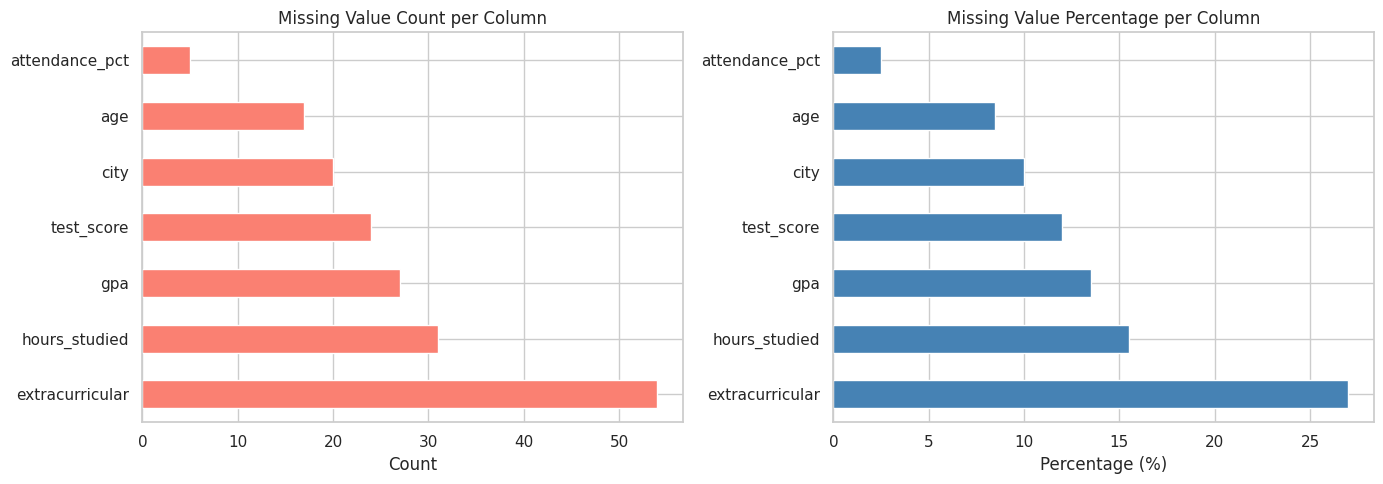

In [58]:
# Bar chart: missing values per column
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: count
missing["missing_count"].plot.barh(ax=axes[0], color="salmon")
axes[0].set_title("Missing Value Count per Column")
axes[0].set_xlabel("Count")

# Right: percentage
missing["missing_percent"].plot.barh(ax=axes[1], color="steelblue")
axes[1].set_title("Missing Value Percentage per Column")
axes[1].set_xlabel("Percentage (%)")

plt.tight_layout()
plt.show()

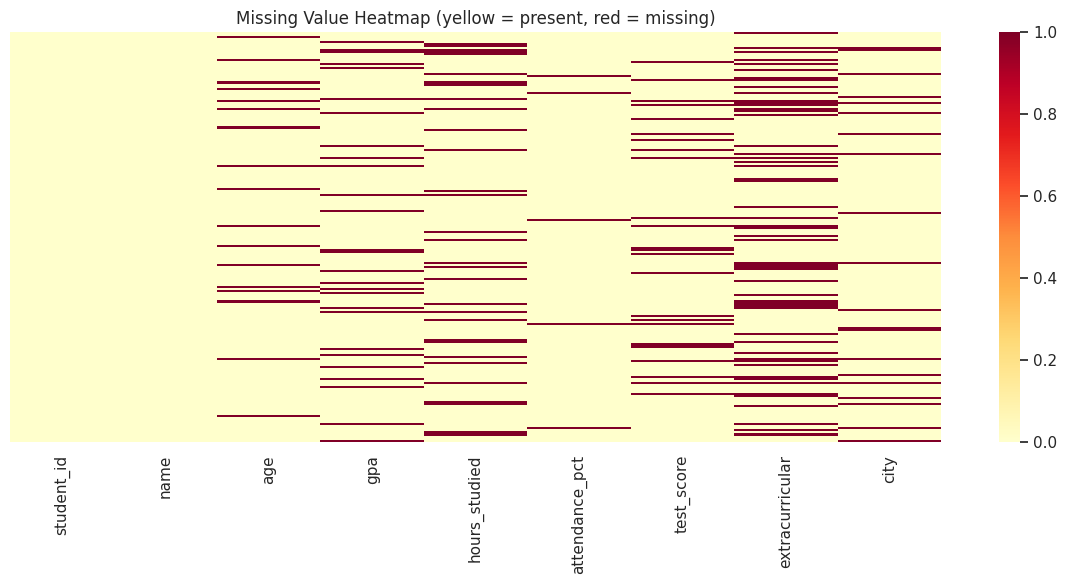

In [59]:
# Heatmap of missing values (white = missing)
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap="YlOrRd", ax=ax)
ax.set_title("Missing Value Heatmap (yellow = present, red = missing)")
plt.tight_layout()
plt.show()

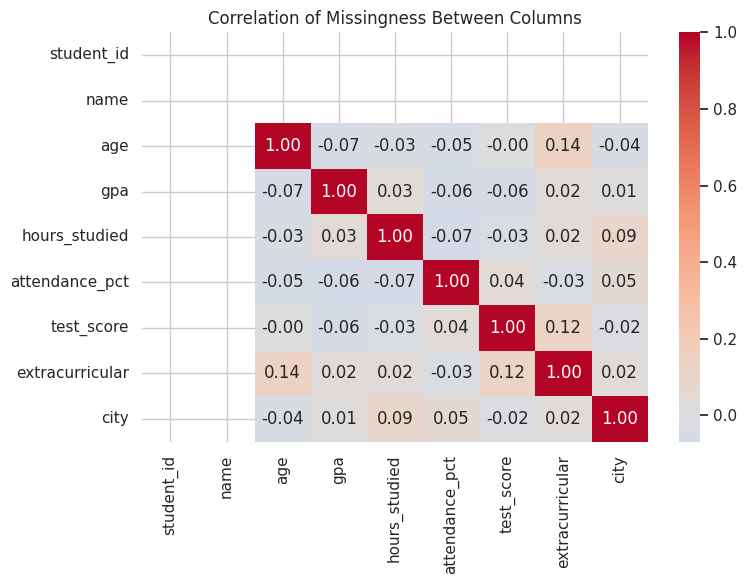

In [60]:
# Correlation of missingness between columns
# If two columns tend to be missing together, it hints at a pattern
missing_corr = df.isnull().corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(missing_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlation of Missingness Between Columns")
plt.tight_layout()
plt.show()

## 4 — Strategy 1: Dropping Missing Values

### 4a — Drop rows with *any* missing value
- Simple but can lose a lot of data
- Appropriate only if missingness is very low

In [61]:
df_drop_any = df.dropna()
print(f"Original rows : {len(df)}")
print(f"After dropna() : {len(df_drop_any)}")
print(f"Rows lost      : {len(df) - len(df_drop_any)} ({(1 - len(df_drop_any)/len(df))*100:.1f}%)")

Original rows : 200
After dropna() : 80
Rows lost      : 120 (60.0%)


### 4b — Drop columns with too many missing values

A common threshold is to drop columns where > 50% of values are missing.

In [62]:
threshold = 0.50
cols_to_drop = df.columns[df.isnull().mean() > threshold].tolist()
print(f"Columns exceeding {threshold*100:.0f}% missing: {cols_to_drop if cols_to_drop else 'None'}")

# Drop rows only where a subset of critical columns have nulls
critical_cols = ["age", "gpa", "test_score"]
df_drop_subset = df.dropna(subset=critical_cols)
print(f"\nAfter dropping rows missing in {critical_cols}: {len(df_drop_subset)} rows remain")

Columns exceeding 50% missing: None

After dropping rows missing in ['age', 'gpa', 'test_score']: 137 rows remain


## 5 — Strategy 2: Filling in Missing Values

There are two main approaches:
- **Using Pandas** — `fillna()`, `interpolate()` (quick, flexible)
- **Using sklearn** — `SimpleImputer`, `KNNImputer`, `IterativeImputer` (pipeline-friendly, smarter)

---

## 5a — Using Pandas `fillna()`

The `fillna()` function lets us replace all `NaN` values automatically. Here are the key patterns:

### Pattern 1: Replace all NaN with a constant value (e.g. 0)

The simplest approach — just pick a value and fill everything with it.

In [63]:
# Replace ALL NaN values with 0
df_fill_zero = df.fillna(0)

print("Before fillna(0):")
print(df[["age", "gpa", "hours_studied"]].head(10))
print("\nAfter fillna(0):")
print(df_fill_zero[["age", "gpa", "hours_studied"]].head(10))
print(f"\nRemaining NaN: {df_fill_zero.isnull().sum().sum()}")

Before fillna(0):
    age   gpa  hours_studied
0  24.0  2.68            4.6
1  21.0  3.89            1.8
2   NaN  2.65            1.6
3  25.0  3.04           34.2
4  22.0   NaN           28.1
5  24.0  2.73            NaN
6  27.0  3.94            NaN
7  20.0  3.92           19.7
8  24.0   NaN            NaN
9  28.0   NaN            NaN

After fillna(0):
    age   gpa  hours_studied
0  24.0  2.68            4.6
1  21.0  3.89            1.8
2   0.0  2.65            1.6
3  25.0  3.04           34.2
4  22.0  0.00           28.1
5  24.0  2.73            0.0
6  27.0  3.94            0.0
7  20.0  3.92           19.7
8  24.0  0.00            0.0
9  28.0  0.00            0.0

Remaining NaN: 0


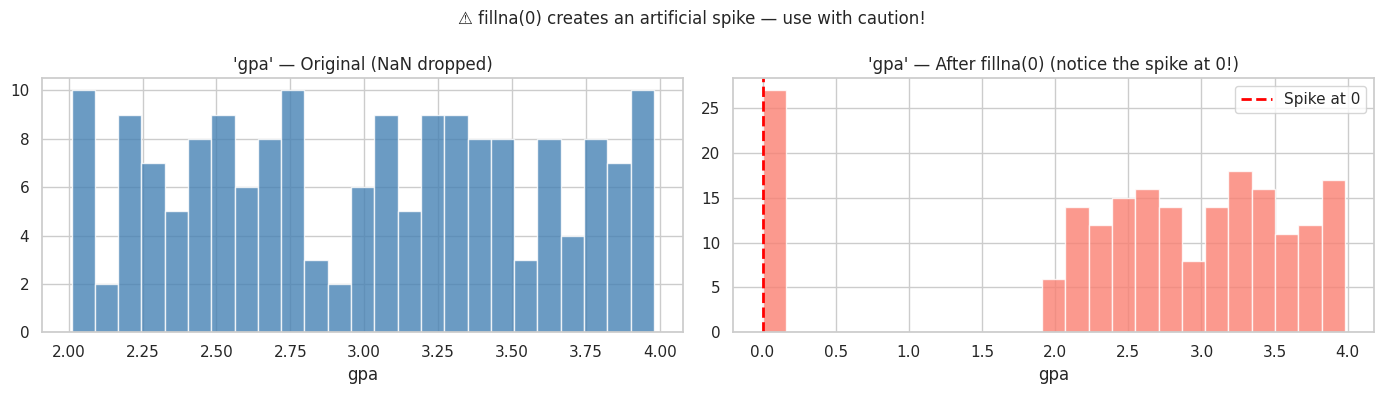

In [64]:
# ⚠️ Problem: filling with 0 can distort distributions!
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
col = "gpa"

axes[0].hist(df[col].dropna(), bins=25, color="steelblue", edgecolor="white", alpha=0.8)
axes[0].set_title(f"'{col}' — Original (NaN dropped)")
axes[0].set_xlabel(col)

axes[1].hist(df_fill_zero[col], bins=25, color="salmon", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--", linewidth=2, label="Spike at 0")
axes[1].set_title(f"'{col}' — After fillna(0) (notice the spike at 0!)")
axes[1].set_xlabel(col)
axes[1].legend()

plt.suptitle("⚠️ fillna(0) creates an artificial spike — use with caution!", fontsize=12)
plt.tight_layout()
plt.show()

### Pattern 2: Replace NaN with column mean or median

More statistically sound — doesn't introduce out-of-range values.

In [65]:
df_fill_median = df.copy()

# Fill each numeric column with its median
numeric_cols_list = df.select_dtypes(include=np.number).columns
for col in numeric_cols_list:
    median_val = df_fill_median[col].median()
    n_filled = df_fill_median[col].isnull().sum()
    df_fill_median[col] = df_fill_median[col].fillna(median_val)
    if n_filled > 0:
        print(f"  {col}: filled {n_filled} NaN → median = {median_val}")

# Fill categorical columns with the most frequent value (mode)
cat_cols_list = df.select_dtypes(include="object").columns
for col in cat_cols_list:
    mode_val = df_fill_median[col].mode()[0]
    n_filled = df_fill_median[col].isnull().sum()
    df_fill_median[col] = df_fill_median[col].fillna(mode_val)
    if n_filled > 0:
        print(f"  {col}: filled {n_filled} NaN → mode = '{mode_val}'")

print(f"\nRemaining NaN: {df_fill_median.isnull().sum().sum()}")

  age: filled 17 NaN → median = 24.0
  gpa: filled 27 NaN → median = 3.04
  hours_studied: filled 31 NaN → median = 22.0
  attendance_pct: filled 5 NaN → median = 72.4
  test_score: filled 24 NaN → median = 74.75
  extracurricular: filled 54 NaN → mode = 'No'
  city: filled 20 NaN → mode = 'Mumbai'

Remaining NaN: 0


In [66]:
# Alias for use in later comparison cells
df_imputed = df_fill_median

### Pattern 3: Forward fill (`ffill`) and Backward fill (`bfill`)

Propagate the **last known value** forward, or the **next known value** backward.  
Best for **time-series or ordered data** where adjacent rows are related.

In [67]:
# Demonstrate ffill and bfill on a small example
sample = pd.DataFrame({
    "day":         [1,    2,    3,    4,    5,    6,    7,    8],
    "temperature": [22.0, np.nan, np.nan, 25.0, np.nan, 27.0, np.nan, np.nan],
})

sample["ffill"] = sample["temperature"].ffill()   # forward fill
sample["bfill"] = sample["temperature"].bfill()   # backward fill

print("Forward Fill (ffill) — carries last known value forward")
print("Backward Fill (bfill) — carries next known value backward\n")
print(sample.to_string(index=False))

Forward Fill (ffill) — carries last known value forward
Backward Fill (bfill) — carries next known value backward

 day  temperature  ffill  bfill
   1         22.0   22.0   22.0
   2          NaN   22.0   25.0
   3          NaN   22.0   25.0
   4         25.0   25.0   25.0
   5          NaN   25.0   27.0
   6         27.0   27.0   27.0
   7          NaN   27.0    NaN
   8          NaN   27.0    NaN


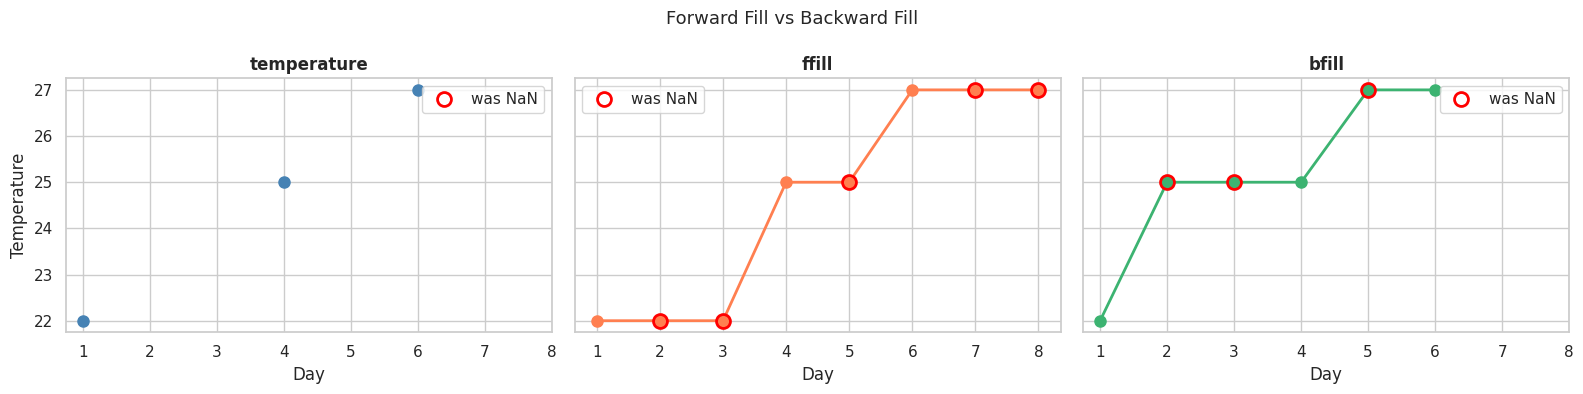

In [68]:
# Visualize ffill vs bfill
fig, axes = plt.subplots(1, 3, figsize=(16, 4), sharey=True)

for ax, (col_name, color) in zip(axes, [("temperature", "steelblue"), ("ffill", "coral"), ("bfill", "mediumseagreen")]):
    ax.plot(sample["day"], sample[col_name], "o-", color=color, markersize=8, linewidth=2)
    # Mark originally missing points
    missing_mask = sample["temperature"].isna()
    ax.plot(sample.loc[missing_mask, "day"], sample.loc[missing_mask, col_name],
            "o", color="red", markersize=10, markerfacecolor="none", markeredgewidth=2,
            label="was NaN")
    ax.set_title(col_name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Day")
    ax.set_xticks(sample["day"])
    ax.legend()

axes[0].set_ylabel("Temperature")
plt.suptitle("Forward Fill vs Backward Fill", fontsize=13)
plt.tight_layout()
plt.show()

### Pattern 3b: Chained `bfill` + `fillna(0)` — Backward fill then zero

A common pattern: first **backward fill** along columns (`axis=0`) to propagate the next known value upward, then fill any **remaining NaN** (e.g., at the bottom where no future value exists) with `0`.

```python
df.bfill(axis=0).fillna(0)
```

> **Note:** Older code may use `df.fillna(method='bfill', axis=0)` — this is equivalent but the `method` parameter was deprecated in pandas 2.x. Use `df.bfill()` instead.

This is useful when:
- You want to use the **nearest future value** as the default
- Any values that **can't be back-filled** (no value below) should default to zero

In [69]:
# Demonstrate chained bfill + fillna(0)
demo = pd.DataFrame({
    "A": [np.nan, 2.0, np.nan, 4.0, np.nan],
    "B": [1.0, np.nan, np.nan, np.nan, 5.0],
    "C": [np.nan, np.nan, 3.0, np.nan, np.nan],
})

demo_bfill = demo.bfill(axis=0)                # step 1: backward fill
demo_bfill_zero = demo.bfill(axis=0).fillna(0)  # step 2: remaining NaN → 0

print("Original DataFrame:")
print(demo.to_string(), "\n")

print("After .bfill(axis=0)  — backward fill down columns:")
print(demo_bfill.to_string(), "\n")

print("After .bfill(axis=0).fillna(0)  — remaining NaN → 0:")
print(demo_bfill_zero.to_string())

Original DataFrame:
     A    B    C
0  NaN  1.0  NaN
1  2.0  NaN  NaN
2  NaN  NaN  3.0
3  4.0  NaN  NaN
4  NaN  5.0  NaN 

After .bfill(axis=0)  — backward fill down columns:
     A    B    C
0  2.0  1.0  3.0
1  2.0  5.0  3.0
2  4.0  5.0  3.0
3  4.0  5.0  NaN
4  NaN  5.0  NaN 

After .bfill(axis=0).fillna(0)  — remaining NaN → 0:
     A    B    C
0  2.0  1.0  3.0
1  2.0  5.0  3.0
2  4.0  5.0  3.0
3  4.0  5.0  0.0
4  0.0  5.0  0.0


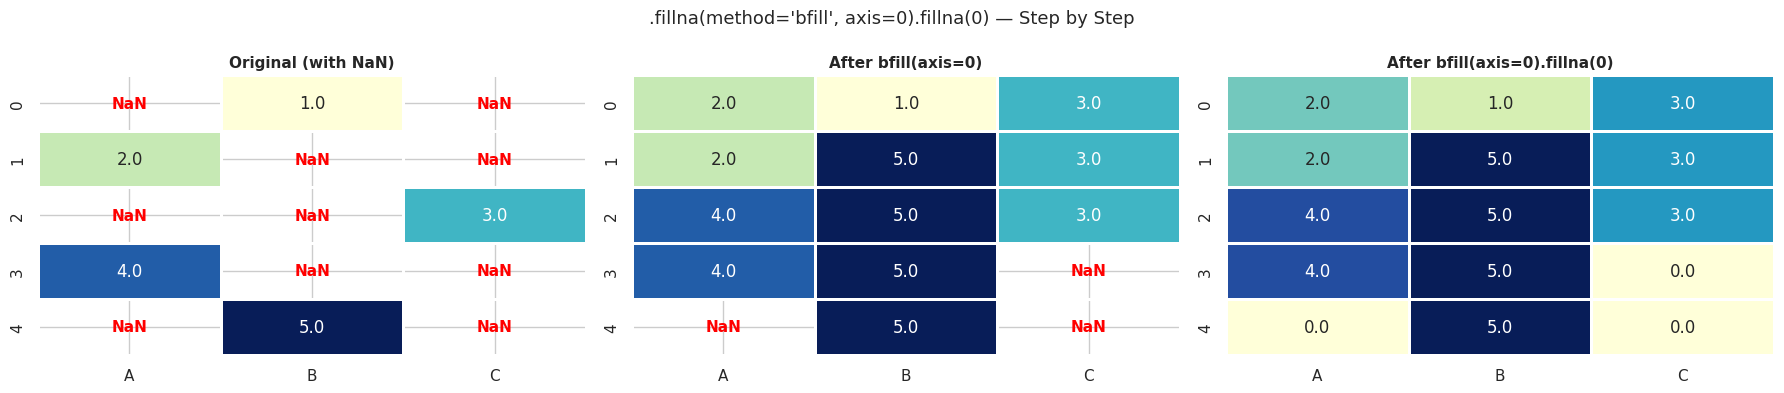

In [70]:
# Visualize the three stages side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
titles = ["Original (with NaN)", "After bfill(axis=0)", "After bfill(axis=0).fillna(0)"]
frames = [demo, demo_bfill, demo_bfill_zero]

for ax, title, data in zip(axes, titles, frames):
    sns.heatmap(data, annot=True, fmt=".1f", cmap="YlGnBu", cbar=False,
                linewidths=1, linecolor="white", ax=ax,
                mask=data.isnull() if data.isnull().any().any() else None)
    # Mark NaN cells with "NaN" text
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if pd.isna(data.iloc[i, j]):
                ax.text(j + 0.5, i + 0.5, "NaN", ha="center", va="center",
                        fontsize=11, color="red", fontweight="bold")
    ax.set_title(title, fontsize=11, fontweight="bold")

plt.suptitle(".fillna(method='bfill', axis=0).fillna(0) — Step by Step", fontsize=13)
plt.tight_layout()
plt.show()

### Pattern 4: Interpolation

`interpolate()` estimates missing values by fitting a line (or curve) between known points.  
More accurate than ffill/bfill when data has a trend.

 day  temperature  ffill  bfill  interpolated
   1         22.0   22.0   22.0          22.0
   2          NaN   22.0   25.0          23.0
   3          NaN   22.0   25.0          24.0
   4         25.0   25.0   25.0          25.0
   5          NaN   25.0   27.0          26.0
   6         27.0   27.0   27.0          27.0
   7          NaN   27.0    NaN          27.0
   8          NaN   27.0    NaN          27.0


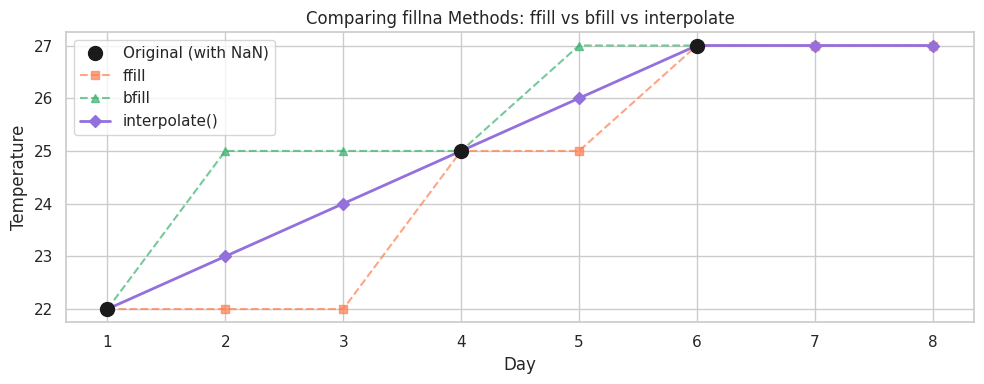

In [71]:
# interpolate() — linear interpolation between known points
sample["interpolated"] = sample["temperature"].interpolate(method="linear")

print(sample[["day", "temperature", "ffill", "bfill", "interpolated"]].to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(sample["day"], sample["temperature"], "ko", markersize=10, label="Original (with NaN)", zorder=5)
ax.plot(sample["day"], sample["ffill"], "s--", color="coral", label="ffill", alpha=0.7)
ax.plot(sample["day"], sample["bfill"], "^--", color="mediumseagreen", label="bfill", alpha=0.7)
ax.plot(sample["day"], sample["interpolated"], "D-", color="mediumpurple", label="interpolate()", linewidth=2)
ax.set_xlabel("Day")
ax.set_ylabel("Temperature")
ax.set_title("Comparing fillna Methods: ffill vs bfill vs interpolate")
ax.set_xticks(sample["day"])
ax.legend()
plt.tight_layout()
plt.show()

### Pandas fillna() — Summary

| Method | Code | Best for |
|--------|------|----------|
| **Constant (e.g. 0)** | `df.fillna(0)` | When NaN genuinely means zero (e.g., missing sales = no sales) |
| **Column mean** | `df[col].fillna(df[col].mean())` | Numeric, roughly symmetric distributions |
| **Column median** | `df[col].fillna(df[col].median())` | Numeric, skewed distributions |
| **Mode** | `df[col].fillna(df[col].mode()[0])` | Categorical columns |
| **Forward fill** | `df[col].ffill()` | Time-series (carry last value forward) |
| **Backward fill** | `df[col].bfill()` | Time-series (carry next value backward) |
| **Interpolation** | `df[col].interpolate()` | Ordered data with a trend |

> **Tip:** You can also pass a **dict** to fillna to use different values per column:
> ```python
> df.fillna({"age": df["age"].median(), "city": "Unknown", "gpa": 0})
> ```

## 5b — Using sklearn Imputers (Automatic, Pipeline-Friendly)

Pandas `fillna()` is great for quick work, but **sklearn imputers** are better for ML pipelines because they:
- Separate **fit** (learn statistics from training data) from **transform** (apply to new data)
- Can be chained in a `Pipeline` with other transformers
- Offer smarter strategies (KNN, iterative/MICE)

| Imputer | Strategy | How it works |
|---------|----------|-------------|
| **SimpleImputer** | mean / median / most_frequent / constant | Column-wise replacement (like `fillna()` but pipeline-ready) |
| **KNNImputer** | K-nearest neighbors | Uses similar rows to estimate missing values |
| **IterativeImputer** | Multivariate (MICE) | Models each feature as a function of others, iteratively |

In [72]:
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer

# Work with numeric columns only for sklearn imputers
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
df_numeric = df[numeric_cols].copy()

print(f"Numeric columns: {numeric_cols}")
print(f"Missing values before imputation:\n{df_numeric.isnull().sum()}\n")

Numeric columns: ['student_id', 'age', 'gpa', 'hours_studied', 'attendance_pct', 'test_score']
Missing values before imputation:
student_id         0
age               17
gpa               27
hours_studied     31
attendance_pct     5
test_score        24
dtype: int64



### SimpleImputer — Column-wise replacement

The simplest automatic approach. Works like `fillna()` but fits into sklearn pipelines.

```python
SimpleImputer(strategy="median")  # also: "mean", "most_frequent", "constant"
```

In [73]:
# SimpleImputer with median strategy
simple_imp = SimpleImputer(strategy="median")
df_simple = pd.DataFrame(
    simple_imp.fit_transform(df_numeric),
    columns=numeric_cols
)

print("SimpleImputer (median) — missing values after:", df_simple.isnull().sum().sum())
print("\nLearned medians (statistics_):")
for col, val in zip(numeric_cols, simple_imp.statistics_):
    print(f"  {col}: {val}")

SimpleImputer (median) — missing values after: 0

Learned medians (statistics_):
  student_id: 100.5
  age: 24.0
  gpa: 3.04
  hours_studied: 22.0
  attendance_pct: 72.4
  test_score: 74.75


### KNNImputer — Uses similar rows

Instead of a global statistic, KNN imputer finds the **k most similar rows** (by non-missing features) and averages their values. This preserves relationships between features.

```python
KNNImputer(n_neighbors=5)  # default k=5
```

In [74]:
# KNNImputer — uses k nearest neighbors
knn_imp = KNNImputer(n_neighbors=5)
df_knn = pd.DataFrame(
    knn_imp.fit_transform(df_numeric),
    columns=numeric_cols
)

print("KNNImputer (k=5) — missing values after:", df_knn.isnull().sum().sum())

KNNImputer (k=5) — missing values after: 0


### IterativeImputer (MICE) — Multivariate

Models **each feature with missing values as a function of all other features**, then iterates until convergence. The most sophisticated built-in option.

```python
IterativeImputer(max_iter=10, random_state=0)
```

In [75]:
# IterativeImputer (MICE) — models each feature from all others
iter_imp = IterativeImputer(max_iter=10, random_state=0)
df_iter = pd.DataFrame(
    iter_imp.fit_transform(df_numeric),
    columns=numeric_cols
)

print("IterativeImputer — missing values after:", df_iter.isnull().sum().sum())

IterativeImputer — missing values after: 0


### Comparing All Automatic Imputers

Let's visualize how each method fills in values differently for the same columns.

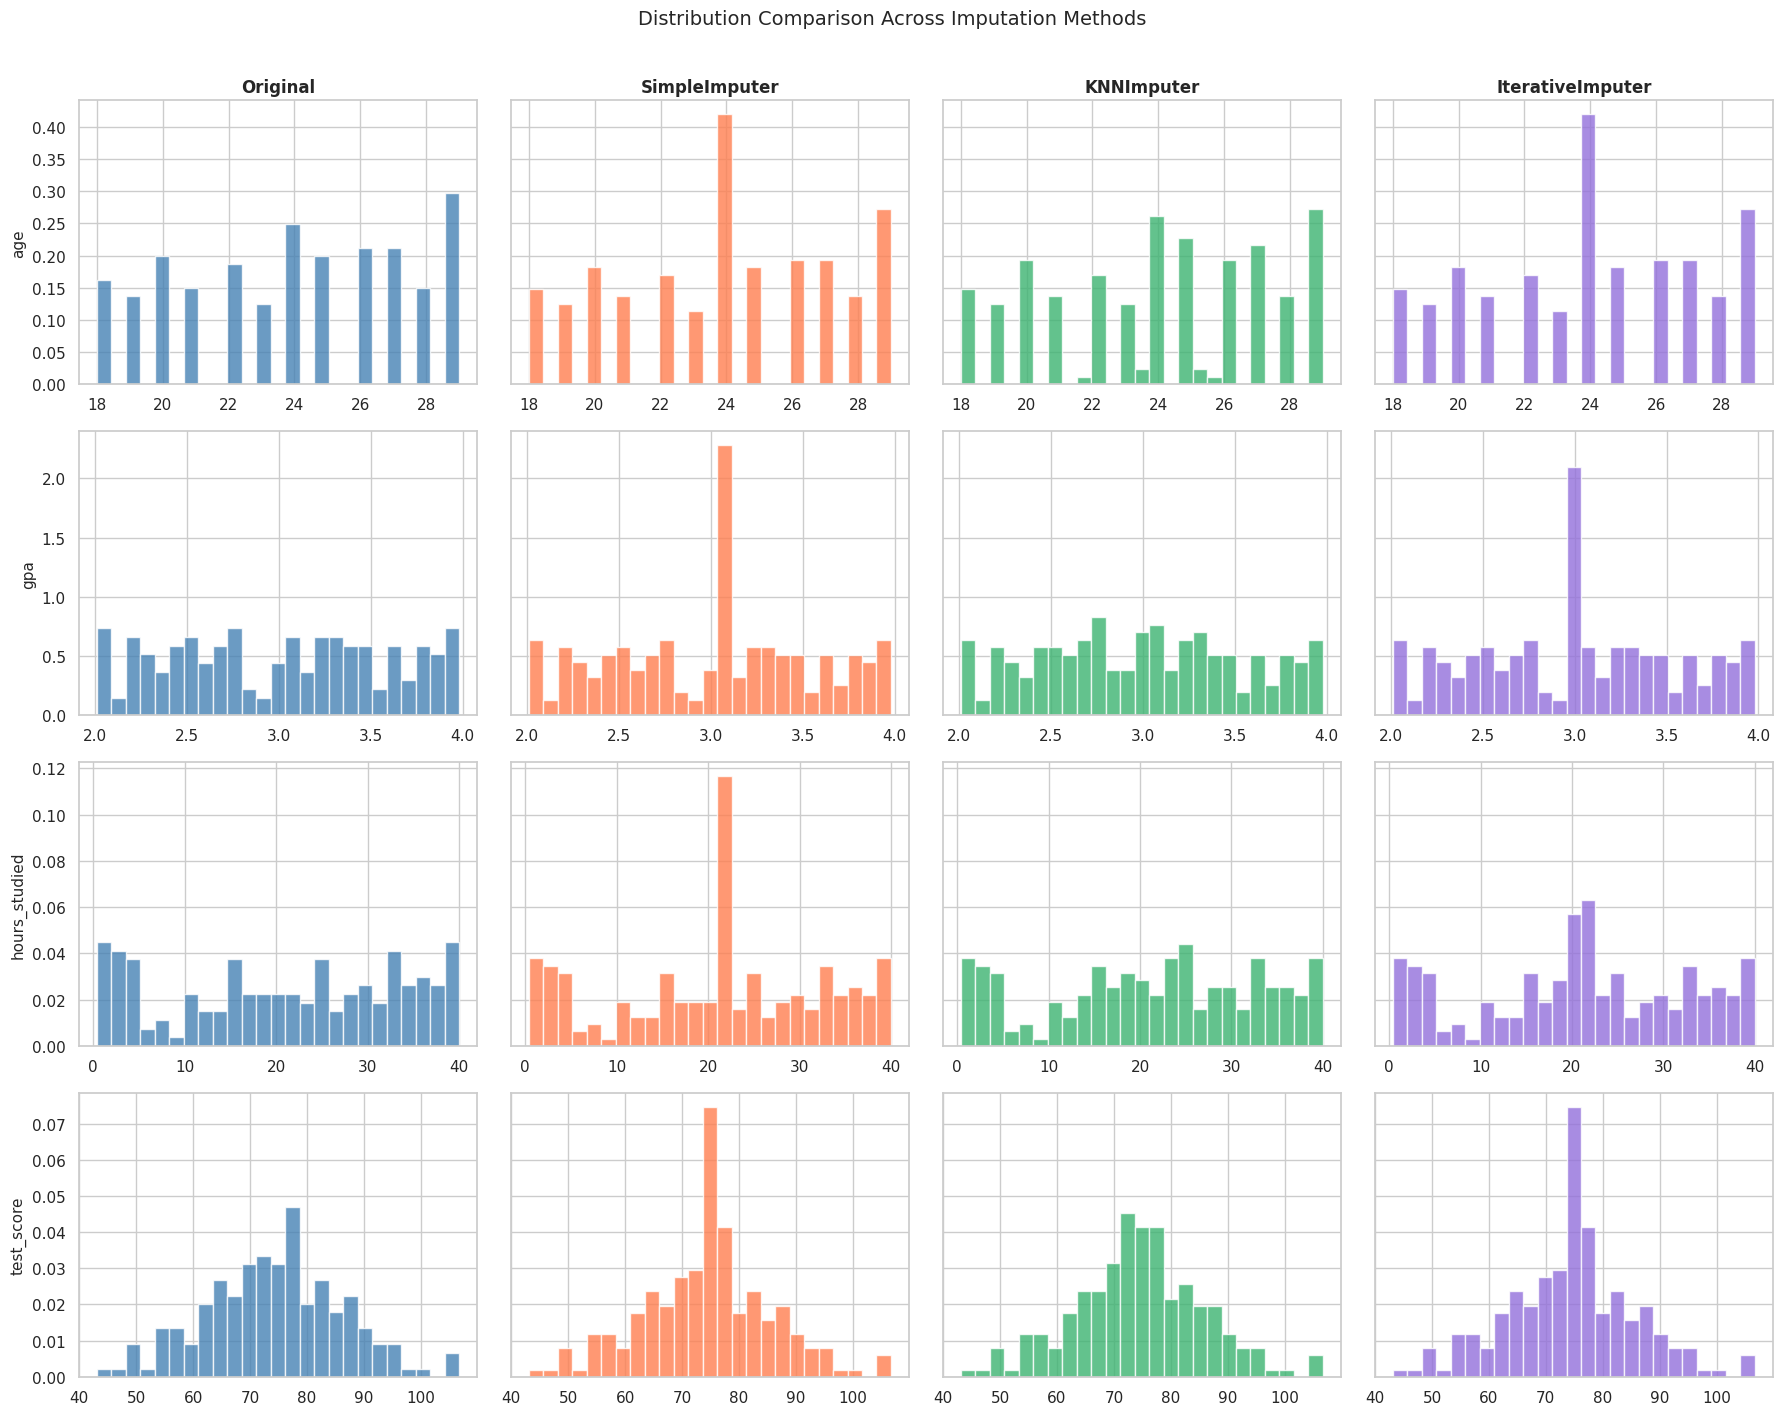

In [76]:
# Compare distributions across all imputation methods
cols_to_compare = ["age", "gpa", "hours_studied", "test_score"]
methods = {
    "Original": df_numeric,
    "SimpleImputer": df_simple,
    "KNNImputer": df_knn,
    "IterativeImputer": df_iter,
}

fig, axes = plt.subplots(len(cols_to_compare), len(methods), figsize=(18, 14),
                          sharey="row")
colors = ["steelblue", "coral", "mediumseagreen", "mediumpurple"]

for j, (method_name, data) in enumerate(methods.items()):
    for i, col in enumerate(cols_to_compare):
        ax = axes[i, j]
        ax.hist(data[col].dropna(), bins=25, color=colors[j],
                edgecolor="white", alpha=0.8, density=True)
        if i == 0:
            ax.set_title(method_name, fontsize=12, fontweight="bold")
        if j == 0:
            ax.set_ylabel(col, fontsize=11)

plt.suptitle("Distribution Comparison Across Imputation Methods", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

In [77]:
# Summary statistics: mean and std across all methods
summary_rows = []
for method_name, data in methods.items():
    for col in cols_to_compare:
        summary_rows.append({
            "Method": method_name,
            "Column": col,
            "Mean": data[col].mean(),
            "Std": data[col].std(),
        })

summary_df = pd.DataFrame(summary_rows)
summary_pivot = summary_df.pivot_table(index="Column", columns="Method",
                                        values=["Mean", "Std"]).round(3)
summary_pivot

Mean                                    \
Method        IterativeImputer KNNImputer Original SimpleImputer   
Column                                                             
age                     23.977     24.004   23.978        23.980   
gpa                      3.005      2.992    3.005         3.009   
hours_studied           20.982     21.199   20.997        21.152   
test_score              74.261     74.313   74.261        74.320   

                           Std                                    
Method        IterativeImputer KNNImputer Original SimpleImputer  
Column                                                            
age                      3.329      3.367    3.481         3.329  
gpa                      0.540      0.547    0.581         0.540  
hours_studied           11.450     11.632   12.452        11.447  
test_score              11.383     11.512   12.139        11.384

## 6 — Visualize: Before vs. After Imputation

Compare distributions to make sure imputation didn't distort the data.

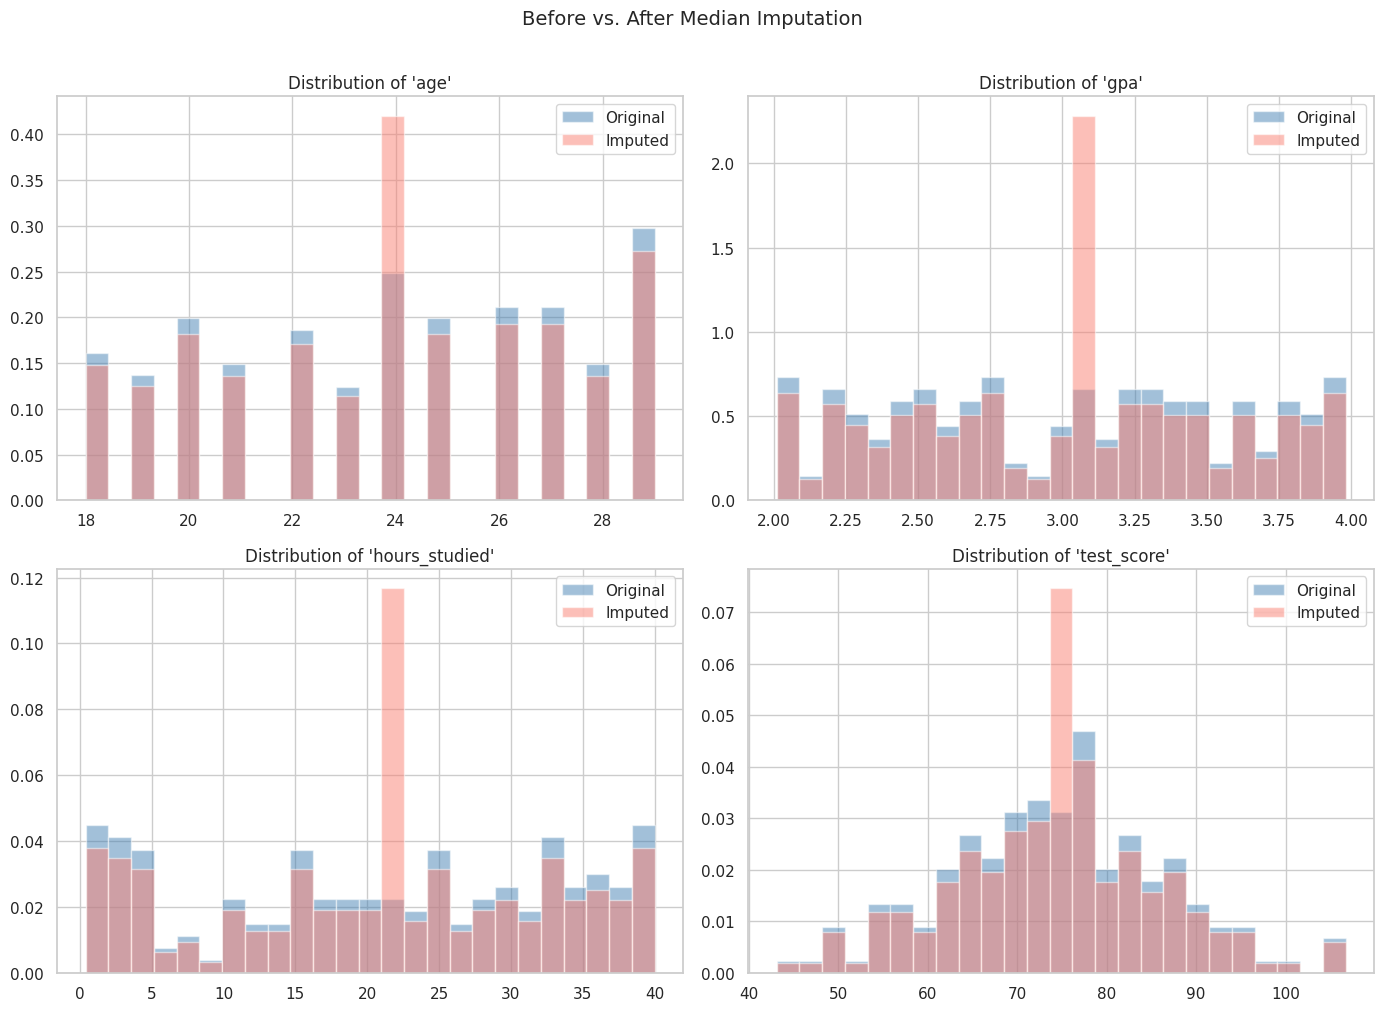

In [78]:
cols_with_missing = ["age", "gpa", "hours_studied", "test_score"]
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, col in zip(axes.flat, cols_with_missing):
    # Original (drop NaN for plotting)
    ax.hist(df[col].dropna(), bins=25, alpha=0.5, label="Original", color="steelblue", density=True)
    # After imputation
    ax.hist(df_imputed[col], bins=25, alpha=0.5, label="Imputed", color="salmon", density=True)
    ax.set_title(f"Distribution of '{col}'")
    ax.legend()

plt.suptitle("Before vs. After Median Imputation", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

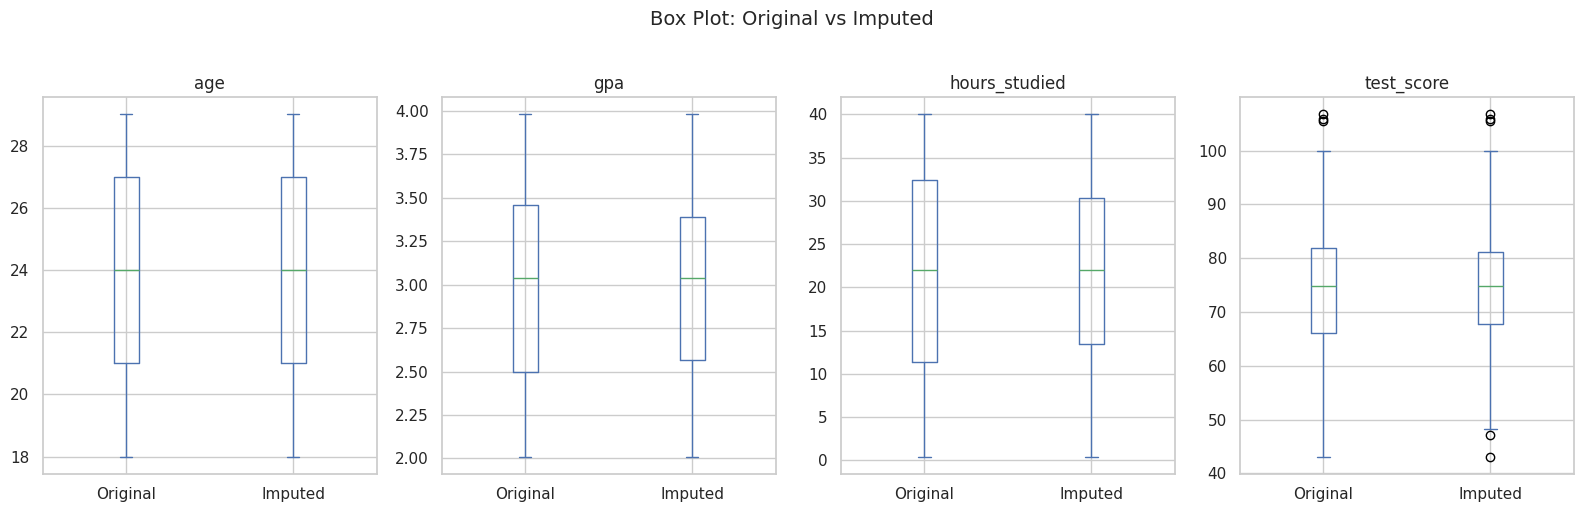

In [79]:
# Box-plots: side-by-side comparison
fig, axes = plt.subplots(1, len(cols_with_missing), figsize=(16, 5))

for ax, col in zip(axes, cols_with_missing):
    combined = pd.DataFrame({
        "Original": df[col],
        "Imputed": df_imputed[col]
    })
    combined.plot.box(ax=ax)
    ax.set_title(col)

plt.suptitle("Box Plot: Original vs Imputed", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 7 — Summary Statistics Comparison

In [80]:
comparison = pd.DataFrame({
    "Original Mean": df[cols_with_missing].mean(),
    "Imputed Mean": df_imputed[cols_with_missing].mean(),
    "Original Std": df[cols_with_missing].std(),
    "Imputed Std": df_imputed[cols_with_missing].std(),
}).round(3)
comparison

,Original Mean,Imputed Mean,Original Std,Imputed Std
age,23.978,23.980,3.481,3.329
gpa,3.005,3.009,0.581,0.540
hours_studied,20.997,21.152,12.452,11.447
test_score,74.261,74.320,12.139,11.384


## 7b — Pros and Cons of Imputing (Inserting Synthetic Data)

When we fill in missing values we are **inserting data that was never observed**. This has real consequences for analysis and modelling.

### Pros

| Benefit | Explanation |
|---------|-------------|
| **Preserves dataset size** | No rows or columns are dropped, so we retain statistical power and sample size |
| **Enables algorithms that can't handle NaN** | Many ML models (SVM, KNN, neural nets) require complete data — imputation makes the data usable |
| **Can preserve distributions** | Smart methods (KNN, MICE) fill values that are consistent with the rest of the data |
| **Maintains feature relationships** | Multivariate imputers (IterativeImputer) model inter-column correlations, keeping structure intact |
| **Pipeline-friendly** | Sklearn imputers fit on training data and transform test data consistently, preventing data leakage |

### Cons

| Drawback | Explanation |
|----------|-------------|
| **Introduces artificial certainty** | Imputed values are treated as "real" — the model doesn't know they were guessed, leading to overconfident predictions |
| **Can distort distributions** | Simple methods (fillna(0), mean) create spikes or reduce variance, biasing statistical tests |
| **May weaken or fabricate correlations** | Mean imputation pushes values toward the center, shrinking true correlations; wrong models can create spurious ones |
| **Masks the missingness pattern** | The fact that a value was missing can itself be informative (e.g., a student skipping a test) — imputation hides this signal |
| **Risk of data leakage** | If imputation statistics are computed on the full dataset (including test data), the model "peeks" at the test set |
| **Garbage in, garbage out** | If the imputation model is poor or the data is MNAR (missing not at random), filled values can be systematically wrong |

### Best practices to mitigate the cons

1. **Add a missingness indicator column** — `df["col_was_missing"] = df["col"].isnull().astype(int)` before imputing, so the model can learn from the missingness pattern
2. **Fit on train, transform on test** — always use sklearn's `fit` / `transform` split to avoid data leakage
3. **Visualize before and after** — compare distributions, correlations, and summary stats to catch distortions early
4. **Try multiple methods and compare** — don't assume one method is best; evaluate with cross-validation
5. **Consider not imputing** — some models (XGBoost, LightGBM) handle NaN natively; sometimes dropping rows is the safer choice

## 8 — Key Takeaways

| Approach | Pros | Cons |
|----------|------|------|
| **Drop rows** | Simple, no bias introduced | Loses data; bad if missingness is high |
| **Drop columns** | Removes noisy features | Loses potentially useful information |
| **Mean/Median imputation** | Preserves dataset size | Can reduce variance; ignores relationships |
| **Mode imputation** | Works for categorical | Over-represents the mode category |

### Rules of thumb
- If < 5% missing → dropping rows is often fine
- If a column has > 50% missing → consider dropping the column
- Always **visualize** distributions before and after imputation
- For production ML: consider more advanced methods (KNN imputer, iterative imputer)

## 9 — Libraries for Handling Missing Values

| Library | What it brings | Key functions / classes |
|---------|---------------|----------------------|
| **pandas** | Built-in detection, dropping, filling, interpolation | `isnull()`, `dropna()`, `fillna()`, `ffill()`, `bfill()`, `interpolate()` |
| **NumPy** | Low-level NaN handling and math that ignores NaN | `np.nan`, `np.isnan()`, `np.nanmean()`, `np.nanmedian()` |
| **scikit-learn** | Pipeline-ready imputers (simple, KNN, iterative/MICE) | `SimpleImputer`, `KNNImputer`, `IterativeImputer` |
| **missingno** | Visualize missingness patterns (matrix, bar, heatmap, dendrogram) | `msno.matrix()`, `msno.bar()`, `msno.heatmap()` |
| **fancyimpute** | Advanced imputers (matrix completion, MICE, nuclear norm) | `IterativeImputer`, `MatrixFactorization`, `SoftImpute` |
| **miceforest** | Fast MICE using LightGBM (handles large datasets) | `ImputationKernel`, supports multiple imputations |
| **autoimpute** | Automated imputation with Bayesian methods + pipeline support | `SingleImputer`, `MultipleImputer`, `MiceImputer` |
| **datawig** | Deep-learning imputer (good for text + tabular) | `SimpleImputer` (trains neural nets per column) |
| **pyjanitor** | Fluent API for cleaning (chained method calls) | `clean_names()`, `remove_empty()`, `fill_direction()` |
| **feature-engine** | ML-focused imputation transformers (sklearn-compatible) | `MeanMedianImputer`, `ArbitraryNumberImputer`, `CategoricalImputer`, `EndTailImputer` |

## 10 — Using `libs.eda` Library Functions

Everything we did above can be achieved with reusable functions from `libs.eda`:

```python
from libs.eda import (
    display_missing,
    plot_missing_bars,
    plot_missing_heatmap,
    compare_distributions,
    compare_boxplots,
    compare_stats,
    add_missing_indicators,
)
```

In [81]:
from libs.eda import (
    display_missing,
    plot_missing_bars,
    plot_missing_heatmap,
    compare_distributions,
    compare_boxplots,
    compare_stats,
    add_missing_indicators,
)

In [82]:
# display_missing — one-liner to see missing counts and percentages
display_missing(df)

,missing_count,missing_percent
extracurricular,54,27.0%
hours_studied,31,15.5%
gpa,27,13.5%
test_score,24,12.0%
city,20,10.0%
age,17,8.5%
attendance_pct,5,2.5%


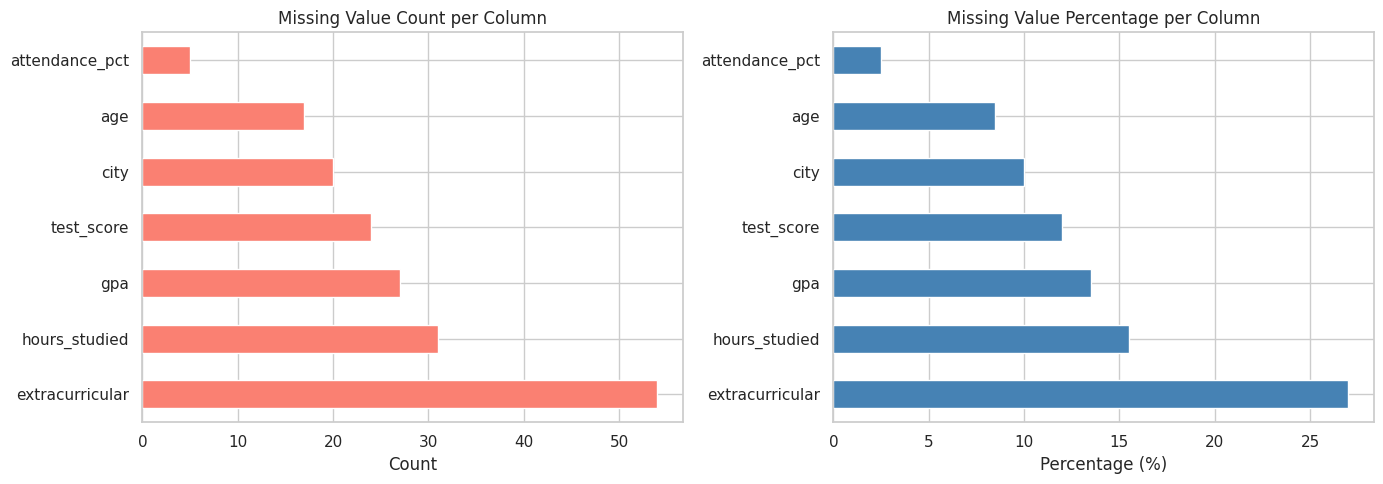

In [83]:
# plot_missing_bars — bar charts of missing count & percentage
plot_missing_bars(df)

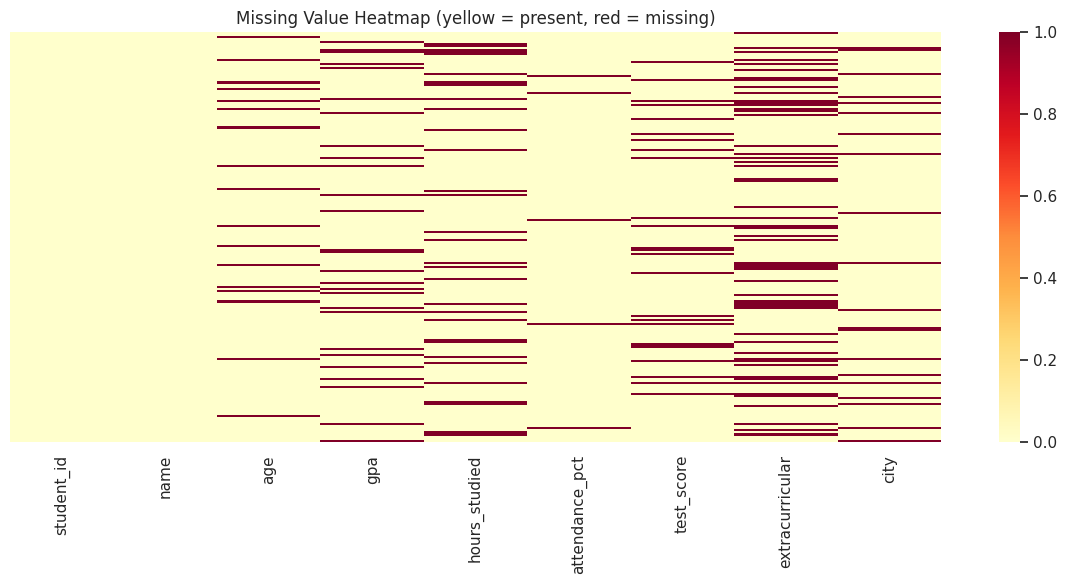

In [84]:
# plot_missing_heatmap — NaN location heatmap
plot_missing_heatmap(df)

In [85]:
# add_missing_indicators — flag which values were NaN before imputing
df_with_flags = add_missing_indicators(df)

# Show the new indicator columns
indicator_cols = [c for c in df_with_flags.columns if c.endswith("_was_missing")]
print(f"Added {len(indicator_cols)} indicator columns: {indicator_cols}\n")
df_with_flags[["age", "age_was_missing", "gpa", "gpa_was_missing"]].head(10)

Added 7 indicator columns: ['age_was_missing', 'gpa_was_missing', 'hours_studied_was_missing', 'attendance_pct_was_missing', 'test_score_was_missing', 'extracurricular_was_missing', 'city_was_missing']



,age,age_was_missing,gpa,gpa_was_missing
0,24.0,0,2.68,0
1,21.0,0,3.89,0
2,NaN,1,2.65,0
3,25.0,0,3.04,0
4,22.0,0,NaN,1
5,24.0,0,2.73,0
6,27.0,0,3.94,0
7,20.0,0,3.92,0
8,24.0,0,NaN,1
9,28.0,0,NaN,1


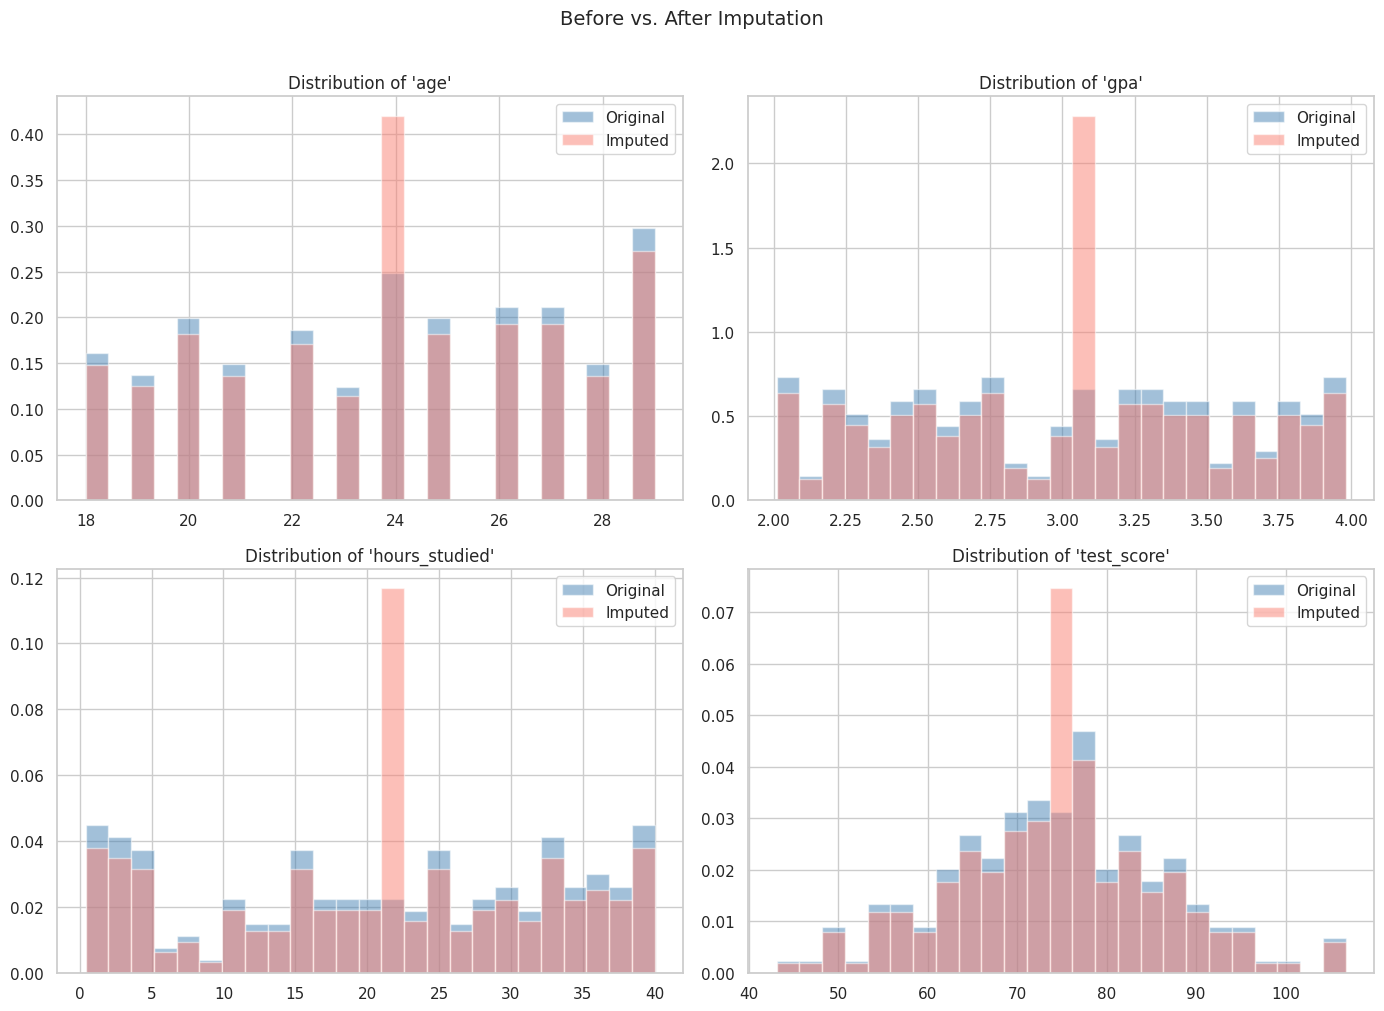

In [86]:
# compare_distributions — overlay histograms before vs after
cols_with_missing = ["age", "gpa", "hours_studied", "test_score"]
compare_distributions(df, df_imputed, cols_with_missing)

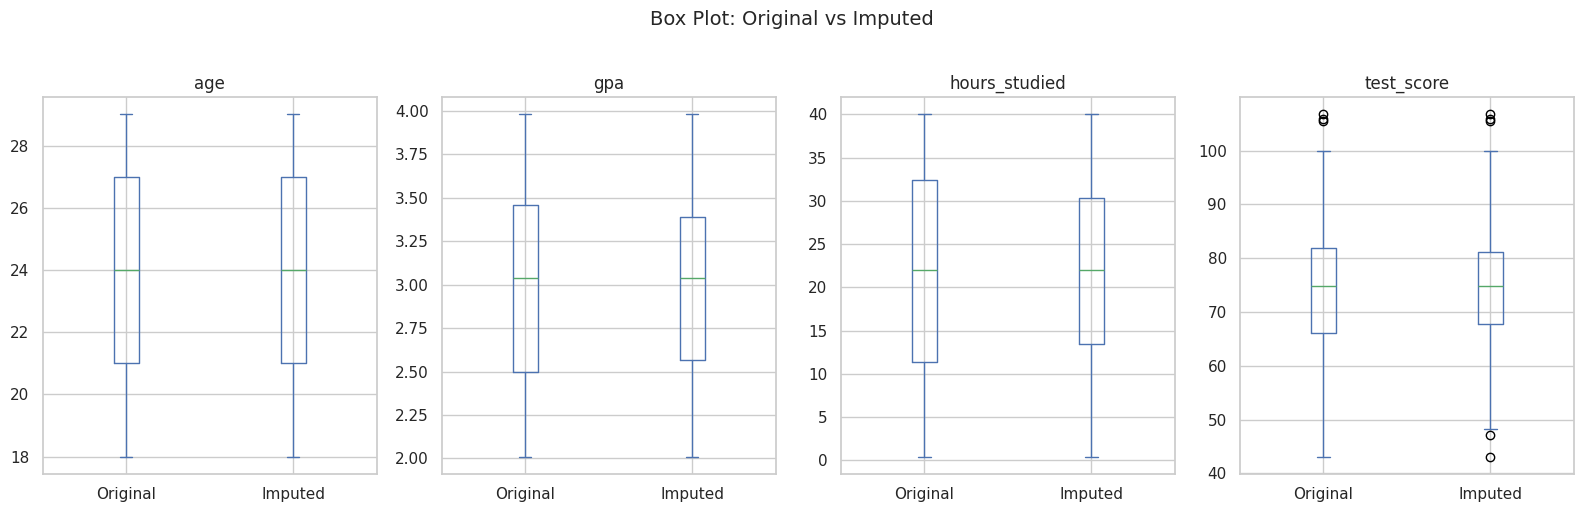

In [87]:
# compare_boxplots — side-by-side box plots
compare_boxplots(df, df_imputed, cols_with_missing)

In [88]:
# compare_stats — mean/std comparison table
compare_stats(df, df_imputed, cols_with_missing)

,Original Mean,Imputed Mean,Original Std,Imputed Std
age,23.978,23.980,3.481,3.329
gpa,3.005,3.009,0.581,0.540
hours_studied,20.997,21.152,12.452,11.447
test_score,74.261,74.320,12.139,11.384


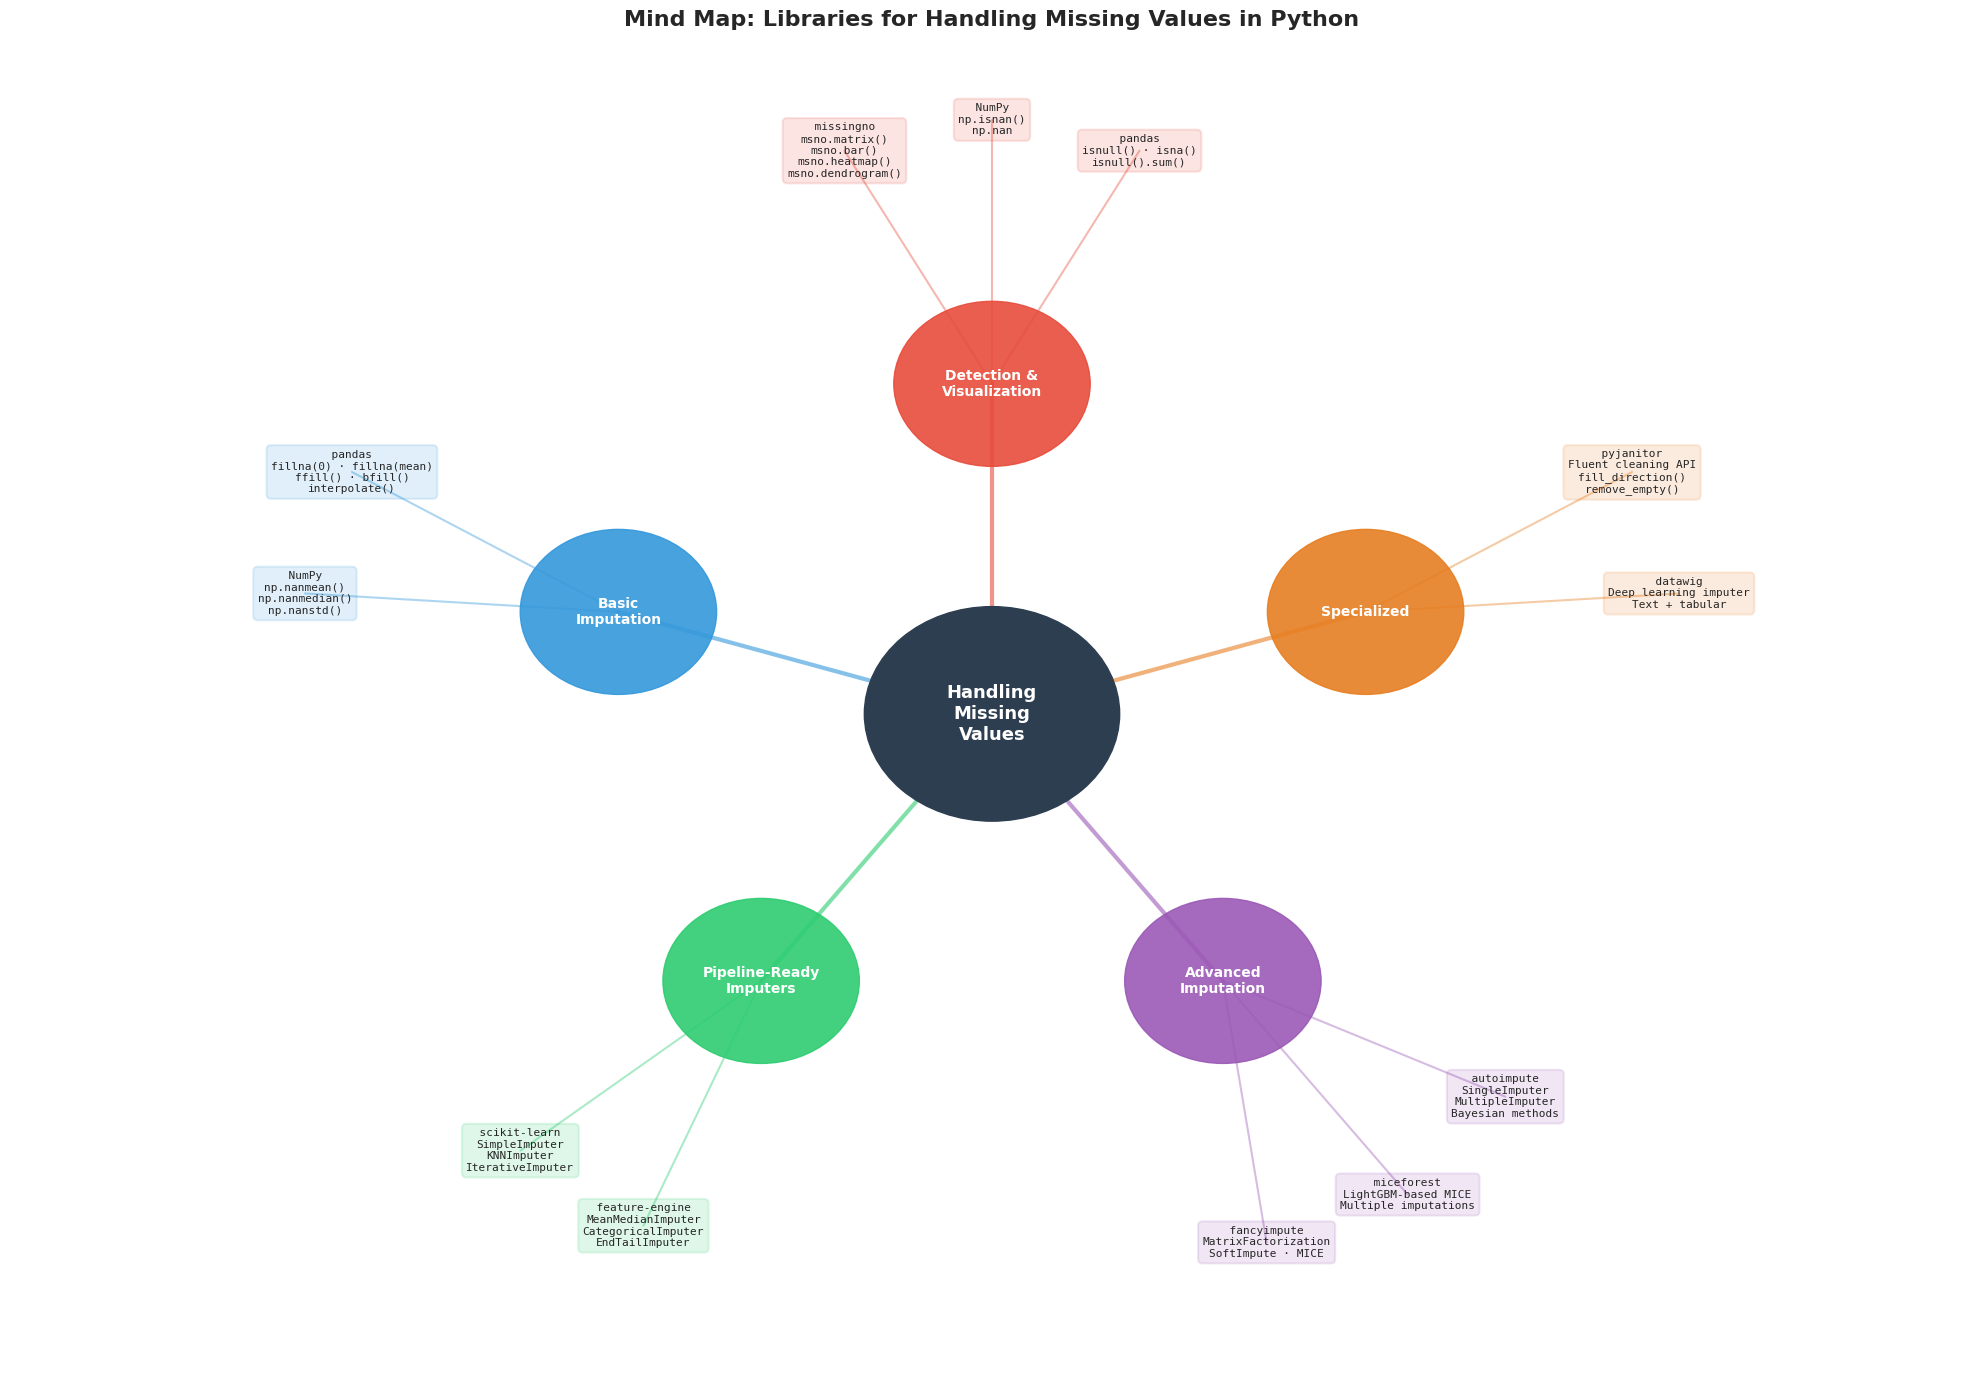

In [89]:
# Mind Map: Libraries for Handling Missing Values
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(20, 14))
ax.set_xlim(-10, 10)
ax.set_ylim(-8, 8)
ax.axis("off")

# ── Central node ──
ax.add_patch(plt.Circle((0, 0), 1.3, color="#2C3E50", zorder=5))
ax.text(0, 0, "Handling\nMissing\nValues", ha="center", va="center",
        fontsize=13, fontweight="bold", color="white", zorder=6)

# ── Category definitions: (label, color, angle_center, items) ──
import math

categories = [
    ("Detection &\nVisualization", "#E74C3C", 90, [
        ("pandas", "isnull() · isna()\nisnull().sum()"),
        ("NumPy", "np.isnan()\nnp.nan"),
        ("missingno", "msno.matrix()\nmsno.bar()\nmsno.heatmap()\nmsno.dendrogram()"),
    ]),
    ("Basic\nImputation", "#3498DB", 162, [
        ("pandas", "fillna(0) · fillna(mean)\nffill() · bfill()\ninterpolate()"),
        ("NumPy", "np.nanmean()\nnp.nanmedian()\nnp.nanstd()"),
    ]),
    ("Pipeline-Ready\nImputers", "#2ECC71", 234, [
        ("scikit-learn", "SimpleImputer\nKNNImputer\nIterativeImputer"),
        ("feature-engine", "MeanMedianImputer\nCategoricalImputer\nEndTailImputer"),
    ]),
    ("Advanced\nImputation", "#9B59B6", 306, [
        ("fancyimpute", "MatrixFactorization\nSoftImpute · MICE"),
        ("miceforest", "LightGBM-based MICE\nMultiple imputations"),
        ("autoimpute", "SingleImputer\nMultipleImputer\nBayesian methods"),
    ]),
    ("Specialized", "#E67E22", 18, [
        ("datawig", "Deep learning imputer\nText + tabular"),
        ("pyjanitor", "Fluent cleaning API\nfill_direction()\nremove_empty()"),
    ]),
]

for cat_label, cat_color, angle_center, items in categories:
    # Category node position
    rad = math.radians(angle_center)
    cx, cy = 4.0 * math.cos(rad), 4.0 * math.sin(rad)

    # Line from center to category
    ax.plot([0, cx], [0, cy], color=cat_color, linewidth=3, alpha=0.6, zorder=2)

    # Category bubble
    ax.add_patch(plt.Circle((cx, cy), 1.0, color=cat_color, alpha=0.9, zorder=4))
    ax.text(cx, cy, cat_label, ha="center", va="center",
            fontsize=10, fontweight="bold", color="white", zorder=5)

    # Fan out library nodes
    n = len(items)
    spread = 28  # degrees between items
    for i, (lib_name, lib_desc) in enumerate(items):
        item_angle = angle_center + (i - (n - 1) / 2) * spread
        item_rad = math.radians(item_angle)
        lx = cx + 3.2 * math.cos(item_rad)
        ly = cy + 3.2 * math.sin(item_rad)

        # Clamp to figure bounds
        lx = max(-9.2, min(9.2, lx))
        ly = max(-7.2, min(7.2, ly))

        # Line from category to library
        ax.plot([cx, lx], [cy, ly], color=cat_color, linewidth=1.5, alpha=0.4, zorder=1)

        # Library box
        bbox = dict(boxstyle="round,pad=0.4", facecolor=cat_color, alpha=0.15,
                    edgecolor=cat_color, linewidth=1.5)
        ax.text(lx, ly, f"  {lib_name}  \n{lib_desc}", ha="center", va="center",
                fontsize=8, fontfamily="monospace", bbox=bbox, zorder=3)

ax.set_title("Mind Map: Libraries for Handling Missing Values in Python",
             fontsize=16, fontweight="bold", pad=20)
plt.tight_layout()
plt.show()